In [20]:
! pip install gensim

In [21]:
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


import os
import re
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import gensim.downloader as api
from collections import Counter


In [22]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Dataset from drive or upload to drive re-run

In [23]:
path = '/content/drive/My Drive/Language-Translation/'
csv='Sentence_pairs_in_English_Hindi.csv'
if os.path.exists(path):
    df = pd.read_csv(os.path.join(path, csv))
else:
     raise ValueError("Please go to your Drive that you mounted to Colab run time\n and creat folde call Language-Translation and upload csv file!")

print(df.head())

                                   English  \
0                       Muiriel is 20 now.   
1                       Muiriel is 20 now.   
2  Education in this world disappoints me.   
3                       That won't happen.   
4                              I miss you.   

                                         Hindi  
0             म्यूरियल अब बीस साल की हो गई है।  
1                   म्यूरियल अब बीस साल की है।  
2  मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।  
3                              वैसा नहीं होगा।  
4                 मुझें तुम्हारी याद आ रही है।  


In [24]:
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
MIN_FREQ = 2
embedding_dim = 300

Function to create English embeddings

In [25]:
def create_English_embedding(df):
    English_train = df['English']
    English_word2vec = api.load('word2vec-google-news-300')

    English_train_sentences = [tokenize(x) for x in English_train]
    print(len(English_train_sentences))

    English_counter = Counter()
    for s in English_train_sentences:
        English_counter.update(s)

    English_valid_words = [w for w, count in English_counter.most_common() if count >= MIN_FREQ]

    English_word2idx = {tok: idx for idx, tok in enumerate(special_tokens)}
    for word in English_valid_words:
        English_word2idx[word] = len(English_word2idx)

    English_idx2word = {idx: word for word, idx in English_word2idx.items()}

    English_embedding_matrix = [np.zeros(embedding_dim), 
                                np.random.normal(scale=0.6, size=(embedding_dim,)),
                                np.zeros(embedding_dim),
                                np.zeros(embedding_dim)]

    for word in English_valid_words:
        if word in English_word2vec:
            English_embedding_matrix.append(English_word2vec[word])
        else:
            English_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    English_embedding_matrix = torch.from_numpy(np.array(English_embedding_matrix)).float()

    if len(English_embedding_matrix) == len(English_word2idx) == len(English_idx2word):
        print(len(English_word2idx))
        print(English_embedding_matrix.shape)

    del English_word2vec 
    gc.collect()

    return English_embedding_matrix, English_word2idx, English_idx2word

Function to create Hindi embeddings

In [26]:
def create_Hindi_embedding(df):
    Hindi_train = df['Hindi']
    Hindi_word2vec = api.load('fasttext-wiki-news-subwords-300')
    
    Hindi_train_sentences = [tokenize(x) for x in Hindi_train]
    print(len(Hindi_train_sentences))

    Hindi_counter = Counter()

    for s in Hindi_train_sentences:
        Hindi_counter.update(s)

    Hindi_valid_words = [w for w, count in Hindi_counter.most_common() if count >= MIN_FREQ]

    Hindi_word2idx={tok: idx for idx, tok in enumerate(special_tokens)}
    for word in Hindi_valid_words:
        Hindi_word2idx[word] = len(Hindi_word2idx)

    Hindi_idx2word = {idx: word for word, idx in Hindi_word2idx.items()}

    Hindi_embedding_matrix = [np.zeros(embedding_dim),
                            np.random.normal(scale=0.6, size=(embedding_dim,)),
                            np.zeros(embedding_dim),
                            np.zeros(embedding_dim)]

    for word in Hindi_valid_words:
        if word in Hindi_word2vec:
            Hindi_embedding_matrix.append(Hindi_word2vec[word])
        else:
            Hindi_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    Hindi_embedding_matrix = torch.from_numpy(np.array(Hindi_embedding_matrix)).float()

    if len(Hindi_embedding_matrix)==len(Hindi_word2idx)==len(Hindi_idx2word):
        print(len(Hindi_word2idx))
        print(Hindi_embedding_matrix.shape)

    del Hindi_word2vec 
    gc.collect()

    return Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word

Load saveed Ebedding or create and save for re-run to drive 

In [32]:
saves_path='/content/drive/My Drive/Language-Translation/Saves'
if os.path.exists(saves_path):
    English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
    Hindi_embedding_matrix = torch.load(os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'rb') as f:
        English_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'rb') as f:
        Hindi_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'rb') as f:
        English_idx2word = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'rb') as f:
        Hindi_idx2word = pickle.load(f)

    print(f"All files Loaded successfully Loaded")

else:
    English_embedding_matrix, English_word2idx, English_idx2word = create_English_embedding(df)
    Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word = create_Hindi_embedding(df)


    os.makedirs(saves_path, exist_ok=True)

    torch.save(English_embedding_matrix, os.path.join(saves_path, 'eng_emb.pt'))
    torch.save(Hindi_embedding_matrix, os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'wb') as f:
        pickle.dump(English_word2idx, f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'wb') as f:
        pickle.dump(Hindi_word2idx, f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'wb') as f:
        pickle.dump(English_idx2word, f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'wb') as f:
        pickle.dump(Hindi_idx2word, f)

    print(f"All files saved successfully to: {saves_path}")

All files Loaded successfully Loaded


Split data into Train, Test, Val

In [34]:
df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.111, random_state=42)

finding max lenght for data sample

99% of English sentences are shorter than: 28.0
99% of Hindi sentences are shorter than: 28.0


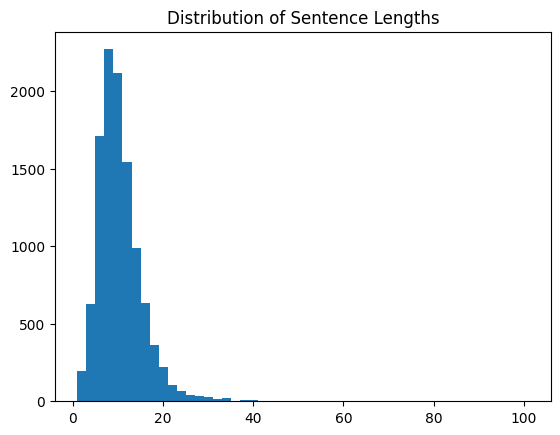

Max Len is 30.0


In [35]:
English_train = df_train['English']
English_train = df_train['Hindi']

eng_lengths = [len(tokenize(s)) for s in English_train]
hin_lengths = [len(tokenize(s)) for s in English_train]


max_len=max(np.percentile(eng_lengths, 99),np.percentile(hin_lengths, 99))+2

print(f"99% of English sentences are shorter than: {np.percentile(eng_lengths, 99)}")
print(f"99% of Hindi sentences are shorter than: {np.percentile(hin_lengths, 99)}")

plt.hist(eng_lengths, bins=50)
plt.title("Distribution of Sentence Lengths")
plt.show()

print(f"Max Len is {max_len}")

Create custom dataset

In [36]:
class TranslationDataset(Dataset):
    def __init__(self, df, English_word2idx, Hindi_word2idx, max_len=20):
        self.df = df
        self.English_word2idx = English_word2idx
        self.Hind_word2idx = Hindi_word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def preprocess(self, text, word2idx):
        tokens = tokenize(text)
        indices = [word2idx.get(tok, 1) for tok in tokens]
        indices = [2] + indices + [3]

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        english_text = self.df.iloc[idx]['English']
        hindi_text = self.df.iloc[idx]['Hindi']

        English_tensor = self.preprocess(english_text, self.English_word2idx)
        Hindi_tensor = self.preprocess(hindi_text, self.Hind_word2idx)

        return English_tensor, Hindi_tensor

Loading data into DataLoaders

In [37]:
BATCH_SIZE=32

train_dataset = TranslationDataset(df_train, English_word2idx, Hindi_word2idx, max_len=30)
val_dataset = TranslationDataset(df_val, English_word2idx, Hindi_word2idx, max_len=30)
test_dataset = TranslationDataset(df_test, English_word2idx, Hindi_word2idx, max_len=30)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Varifying that DataLoader and Custom dataset is working fine

In [38]:
English_batch, Hindi_batch = next(iter(train_loader))

print(f"English Batch Shape: {English_batch.shape}")
print(f"Hindi Batch Shape: {Hindi_batch.shape}")

first_sentence = English_batch[0].tolist()
decoded = [English_idx2word.get(idx, '<UNK>') for idx in first_sentence]
print("\nFirst English Sentence in Batch:")
print(" ".join(decoded))

English Batch Shape: torch.Size([32, 30])
Hindi Batch Shape: torch.Size([32, 30])

First English Sentence in Batch:
<SOS> the sun is in the sky <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
